# CNN Model for Sentiment Analysis

In [2]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv("data/cleaned_imdb.csv")
print(df.shape)
print(df.columns)
df.head()

(50000, 3)
Index(['review', 'sentiment', 'clean_review'], dtype='object')


,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,1,one reviewers mentioned watching oz episode yo...
1,A wonderful little production. <br /><br />The...,1,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,1,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,0,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,petter matteis love time money visually stunni...


In [5]:
#drop empty rosw
df = df[["clean_review", "sentiment"]].dropna()

#ensure sentiment is 0 or 1 int
df["sentiment"] = pd.to_numeric(df["sentiment"], errors="coerce")
df = df[df["sentiment"].isin([0, 1])]
df["sentiment"] = df["sentiment"].astype(int)

#checking
print(df.shape)
print(df["sentiment"].value_counts())

(50000, 2)
sentiment
1    25000
0    25000
Name: count, dtype: int64


In [6]:
#building feature matrix X and y
X = df["clean_review"].astype(str)
y = df["sentiment"]

#debug
print("Example review:\n", X.iloc[0][:200])

Example review:
 one reviewers mentioned watching oz episode youll hooked right exactly happened methe first thing struck oz brutality unflinching scenes violence set right word go trust not show faint hearted timid s


### Splitting

In [8]:
#split 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train:", len(X_train), "Test:", len(X_test))

Train: 35000 Test: 15000


### TF-IDF Vectorizer

In [10]:
# #unigrams and bigrams are used to capture indiv words and short phrases
# tfidf = TfidfVectorizer(
#     max_features=10000,
#     ngram_range=(1, 2)
# )

# X_train_vec = tfidf.fit_transform(X_train)
# X_test_vec = tfidf.transform(X_test)

# print(X_train_vec.shape, X_test_vec.shape)

TF-IDF was used to convert the movie reviews into numerical features. This allows the classidier to learn from the improtance of words and short phrases.

### Tokenizing text

In [13]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000
max_len = 200

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

print("Padded shapes:", X_train_pad.shape, X_test_pad.shape)

Padded shapes: (35000, 200) (15000, 200)


Tokenizing was used to turn text into matrixes that CNN filters can work on to detect local patterns.

### Building the CNN Model

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

# Build CNN model
cnn = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn.summary()

# Train
history = cnn.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 200, 128)          1280000   
                                                                 
 conv1d (Conv1D)             (None, 196, 128)          82048     
                                                                 
 global_max_pooling1d (Globa  (None, 128)              0         
 lMaxPooling1D)                                                  
                                                                 
 dense (Dense)               (None, 64)                8256      
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 65        
                                                        

### Evaluating

In [17]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

y_pred_prob = cnn.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy: ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Confusion matrix:\n", cm)

469/469 [==============================] - 3s 6ms/step
Accuracy:  0.8822
              precision    recall  f1-score   support

           0       0.87      0.89      0.88      7500
           1       0.89      0.87      0.88      7500

    accuracy                           0.88     15000
   macro avg       0.88      0.88      0.88     15000
weighted avg       0.88      0.88      0.88     15000

Confusion matrix:
 [[6689  811]
 [ 956 6544]]


Confusion matrix(y_test, y_pred) [[6689  811]
 [ 956 6544]]


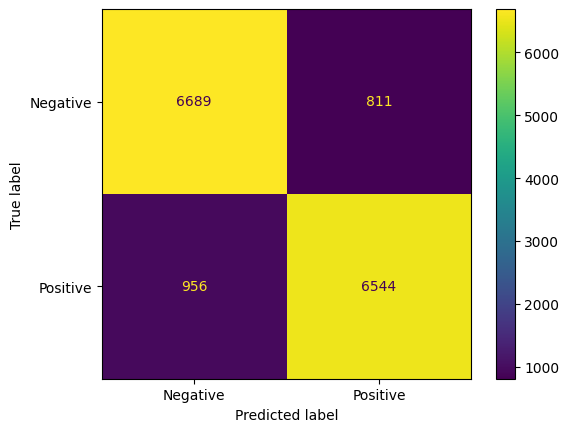

In [18]:
print("Confusion matrix(y_test, y_pred)", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot(values_format="d")
plt.show()

### Tuning the CNN

In [20]:
results = []

for filters in [64, 128, 256]:
    for kernel_size in [3, 5, 7]:
        model = Sequential([
            Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
            Conv1D(filters=filters, kernel_size=kernel_size, activation='relu'),
            GlobalMaxPooling1D(),
            Dense(64, activation='relu'),
            Dropout(0.5),
            Dense(1, activation='sigmoid')
        ])
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        
        model.fit(X_train_pad, y_train, epochs=3, batch_size=64, validation_split=0.1, verbose=0)
        
        loss, acc = model.evaluate(X_test_pad, y_test, verbose=0)
        results.append((filters, kernel_size, acc))
        print(f"Filters={filters}, Kernel={kernel_size}, Accuracy={acc:.4f}")

print("\nBest config:", max(results, key=lambda x: x[2]))

Filters=64, Kernel=3, Accuracy=0.8803
Filters=64, Kernel=5, Accuracy=0.8773
Filters=64, Kernel=7, Accuracy=0.8757
Filters=128, Kernel=3, Accuracy=0.8714
Filters=128, Kernel=5, Accuracy=0.8795
Filters=128, Kernel=7, Accuracy=0.8727
Filters=256, Kernel=3, Accuracy=0.8815
Filters=256, Kernel=5, Accuracy=0.8703
Filters=256, Kernel=7, Accuracy=0.8790

Best config: (256, 3, 0.8815333247184753)


Multiple filters and kernels were tested for the CNN classifier and among the tested values, filter = 256, kernel = 3 achieved the highest accuracy of 0.8815 on the test set.